# Potential Talents


In [54]:
import pandas as pd
import spacy

nlp = spacy.load('en_core_web_sm')

df = pd.read_excel('potential-talents.xlsx')
df = df.drop('fit', axis = 1)
df

,id,job_title,location,connection
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500+
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+
...,...,...,...,...
99,100,Aspiring Human Resources Manager | Graduating ...,"Cape Girardeau, Missouri",103
100,101,Human Resources Generalist at Loparex,"Raleigh-Durham, North Carolina Area",500+
101,102,Business Intelligence and Analytics at Travelers,Greater New York City Area,49
102,103,Always set them up for Success,Greater Los Angeles Area,500+


# Section 1: Exploratory Data Analysis

In [55]:
df['location'].value_counts()

location
Kanada                                 12
Raleigh-Durham, North Carolina Area     8
Houston, Texas Area                     8
Greater New York City Area              7
Houston, Texas                          7
Denton, Texas                           6
San Francisco Bay Area                  5
Greater Philadelphia Area               5
İzmir, Türkiye                          4
Lake Forest, California                 4
Atlanta, Georgia                        4
Chicago, Illinois                       2
Austin, Texas Area                      2
Greater Atlanta Area                    2
Amerika Birleşik Devletleri             2
Long Beach, California                  1
Milpitas, California                    1
Greater Chicago Area                    1
Torrance, California                    1
Greater Los Angeles Area                1
Bridgewater, Massachusetts              1
Lafayette, Indiana                      1
Kokomo, Indiana Area                    1
Las Vegas, Nevada Area   

## Describe the count, unique, top values, and their frequency

In [56]:
df['connection'].describe()

count       104
unique       33
top       500+ 
freq         44
Name: connection, dtype: object

## Distribution of the values in the connection column

In [57]:
df['connection'].value_counts()

connection
500+     44
85        7
61        7
44        6
1         5
2         4
4         2
7         2
57        2
390       2
103       1
48        1
18        1
71        1
19        1
415       1
9         1
64        1
39        1
155       1
349       1
174       1
40        1
50        1
268       1
455       1
52        1
409       1
212       1
16        1
5         1
82        1
49        1
Name: count, dtype: int64

## Word Clouds of both connection and location

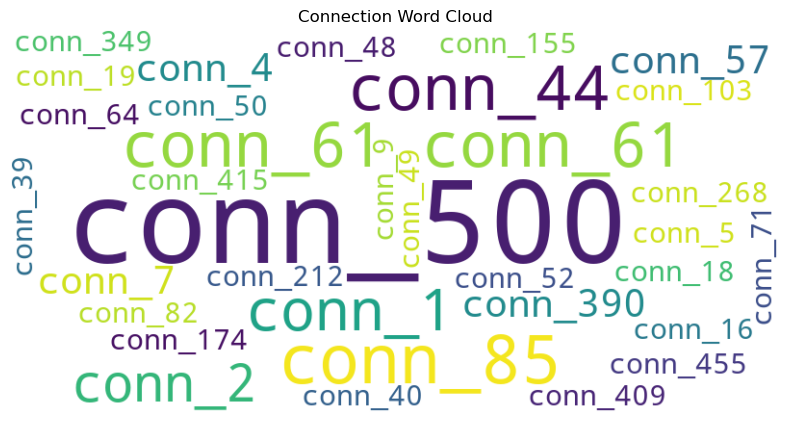

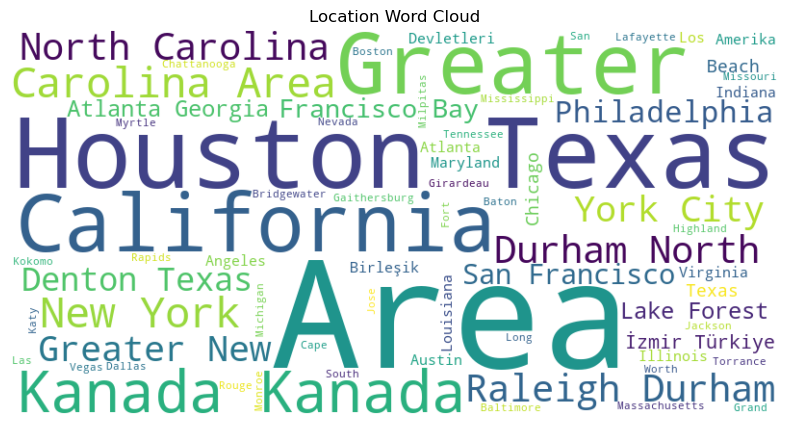

In [45]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Create text from the columns
location_text = " ".join(df["location"].astype(str))

connection_text = " ".join(
    "conn_" + str(x)
    for x in df["connection"].dropna()
)

# Connection Word Cloud
plt.figure(figsize=(10, 5))
wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(connection_text)

plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Connection Word Cloud")
plt.show()

# Location Word Cloud
plt.figure(figsize=(10, 5))
wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(location_text)

plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Location Word Cloud")
plt.show()

## Finding the bert scores

In [59]:
from sentence_transformers import SentenceTransformer, util
import pandas as pd
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

targets = [
    "Aspiring Human Resources",
    "Seeking Human Resources"
]

emb_targets = model.encode(targets, convert_to_tensor=True)
emb_jobs = model.encode(df["job_title"].astype(str).tolist(), convert_to_tensor=True)

similarities = util.cos_sim(emb_targets, emb_jobs)

# Best match from either target phrase
df["bert_score"] = similarities.max(dim=0).values.cpu().numpy()

df = df.sort_values(by="bert_score", ascending=False)

In [60]:
df

,id,job_title,location,connection,bert_score
16,17,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.949807
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.949807
45,46,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.949807
57,58,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.949807
96,97,Aspiring Human Resources Professional,"Kokomo, Indiana Area",71,0.949807
...,...,...,...,...,...
86,87,Bachelor of Science in Biology from Victoria U...,"Baltimore, Maryland",40,0.222139
92,93,Admissions Representative at Community medical...,"Long Beach, California",9,0.202660
102,103,Always set them up for Success,Greater Los Angeles Area,500+,0.148272
101,102,Business Intelligence and Analytics at Travelers,Greater New York City Area,49,0.146150


# Matching the Keywords

In [61]:
from spacy.matcher import Matcher
matcher = Matcher(nlp.vocab)

In [62]:
docs = [nlp(title) for title in df["job_title"].astype(str)]

In [63]:
from spacy.matcher import PhraseMatcher

matcher = PhraseMatcher(nlp.vocab)

phrases = [
    "Aspiring Human Resources",
    "Seeking Human Resources"
]

patterns = [nlp.make_doc(text) for text in phrases]

matcher.add("HR", patterns)

for doc in docs:
    matches = matcher(doc)
    for match_id, start, end in matches:
        
        print(doc.text)
        print("Matched:", doc[start:end].text)


Aspiring Human Resources Professional
Matched: Aspiring Human Resources
Aspiring Human Resources Professional
Matched: Aspiring Human Resources
Aspiring Human Resources Professional
Matched: Aspiring Human Resources
Aspiring Human Resources Professional
Matched: Aspiring Human Resources
Aspiring Human Resources Professional
Matched: Aspiring Human Resources
Aspiring Human Resources Professional
Matched: Aspiring Human Resources
Aspiring Human Resources Professional
Matched: Aspiring Human Resources
Aspiring Human Resources Specialist
Matched: Aspiring Human Resources
Aspiring Human Resources Specialist
Matched: Aspiring Human Resources
Aspiring Human Resources Specialist
Matched: Aspiring Human Resources
Aspiring Human Resources Specialist
Matched: Aspiring Human Resources
Aspiring Human Resources Specialist
Matched: Aspiring Human Resources
Seeking Human Resources Position
Matched: Seeking Human Resources
Seeking Human Resources Opportunities
Matched: Seeking Human Resources
Seeking H

In [64]:
from spacy.matcher import PhraseMatcher
import pandas as pd

matcher = PhraseMatcher(nlp.vocab)

phrases = [
    "Aspiring Human Resources",
    "Seeking Human Resources"
]

patterns = [nlp.make_doc(text) for text in phrases]

matcher.add("HR", patterns)


def hr_fitness_score(text):
    
    doc = nlp(text)
    
    matches = matcher(doc)
    
    if len(matches) > 0:
        return 1.0
    
    return 0.0


df["hr_fitness_score"] = df["job_title"].apply(hr_fitness_score)

## Using FastText to find the similarity

In [65]:
from gensim.models.fasttext import FastText
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

sentences = [
    title.lower().split()
    for title in df["job_title"].astype(str)
]

ft_model = FastText(
    sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

In [66]:
def sentence_vector(sentence):

    words = sentence.lower().split()

    vectors = [
        ft_model.wv[w]
        for w in words
        if w in ft_model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(ft_model.vector_size)

    return np.mean(vectors, axis=0)

In [67]:
target_vec = sentence_vector(target)

fasttext_scores = []

for title in df["job_title"]:

    vec = sentence_vector(str(title))

    score = cosine_similarity(
        [target_vec],
        [vec]
    )[0][0]

    fasttext_scores.append(score)

df["fasttext_score"] = fasttext_scores

## Finding TFIDF Scores

In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

documents = df["job_title"].fillna("").astype(str).tolist()

target = "Aspiring Human Resources Seeking Human Resources"

vectorizer = TfidfVectorizer(stop_words="english")

X = vectorizer.fit_transform(documents + [target])

job_vectors = X[:-1]
target_vector = X[-1]

similarities = cosine_similarity(job_vectors, target_vector)

df["tfidf_score"] = similarities.flatten()

df.sort_values("tfidf_score", ascending=False).head(10)


,id,job_title,location,connection,bert_score,hr_fitness_score,fasttext_score,tfidf_score,fit
16,17,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.949807,1.0,0.903381,0.612985,0.897731
96,97,Aspiring Human Resources Professional,"Kokomo, Indiana Area",71,0.949807,1.0,0.903381,0.612985,0.897731
20,21,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.949807,1.0,0.903381,0.612985,0.897731
32,33,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.949807,1.0,0.903381,0.612985,0.897731
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.949807,1.0,0.903381,0.612985,0.897731
57,58,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.949807,1.0,0.903381,0.612985,0.897731
45,46,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.949807,1.0,0.903381,0.612985,0.897731
48,49,Aspiring Human Resources Specialist,Greater New York City Area,1,0.928035,1.0,0.917421,0.565568,0.888836
23,24,Aspiring Human Resources Specialist,Greater New York City Area,1,0.928035,1.0,0.917421,0.565568,0.888836
5,6,Aspiring Human Resources Specialist,Greater New York City Area,1,0.928035,1.0,0.917421,0.565568,0.888836


## Configuring the fit score based on different weights assigned to bert score, tfidf, hr_fitness_score and fasttext scores.

In [ ]:
bert_w = df['bert_score'].std()
tfidf_w = df['tfidf_score'].std()
hr_w = df['hr_fitness_score'].std()
ft_w = df['fasttext_score'].std()

total = bert_w + tfidf_w + hr_w + ft_w

bert_w /= total
tfidf_w /= total
hr_w /= total
ft_w /= total

df['fit'] = (
    bert_w * df['bert_score']
    + tfidf_w * df['tfidf_score']
    + hr_w * df['hr_fitness_score'] 
    + ft_w * df['fasttext_score']
)

df.sort_values("fit", ascending=False).head(10)

In [69]:
features = [
    "bert_score",
    "tfidf_score",
    "hr_fitness_score",
    "fasttext_score"
]

X = df[features]
y = df["fit"]

## Finding the pairs in which (a,b) means the fitness score for a is greater than the fitness score for b

In [70]:
import itertools
import numpy as np

X_pairs = []
y_pairs = []


for i, j in itertools.combinations(range(len(df)), 2):

    score_i = df.iloc[i]["fit"]
    score_j = df.iloc[j]["fit"]


    if score_i > score_j:

        a = df.loc[i, features].to_numpy(dtype=np.float32)
        b = df.loc[j, features].to_numpy(dtype=np.float32)

        X_pairs.append([a,b])
        y_pairs.append(1)


    elif score_j > score_i:

        a = df.loc[j, features].to_numpy(dtype=np.float32)
        b = df.loc[i, features].to_numpy(dtype=np.float32)

        X_pairs.append([a,b])
        y_pairs.append(1)

In [179]:
X_pairs

[[array([0.5732681 , 0.22987089, 0.        ], dtype=float32),
  array([0.5034565, 0.       , 0.       ], dtype=float32)],
 [array([0.5732681 , 0.22987089, 0.        ], dtype=float32),
  array([0.7578105, 0.3536191, 1.       ], dtype=float32)],
 [array([0.5732681 , 0.22987089, 0.        ], dtype=float32),
  array([0.8079876 , 0.42277923, 1.        ], dtype=float32)],
 [array([0.5732681 , 0.22987089, 0.        ], dtype=float32),
  array([0.35165715, 0.        , 0.        ], dtype=float32)],
 [array([0.5732681 , 0.22987089, 0.        ], dtype=float32),
  array([0.3457893, 0.       , 0.       ], dtype=float32)],
 [array([0.5732681 , 0.22987089, 0.        ], dtype=float32),
  array([0.5957887 , 0.20757204, 0.        ], dtype=float32)],
 [array([0.5732681 , 0.22987089, 0.        ], dtype=float32),
  array([0.5732681 , 0.22987089, 0.        ], dtype=float32)],
 [array([0.5732681 , 0.22987089, 0.        ], dtype=float32),
  array([0.5732681 , 0.22987089, 0.        ], dtype=float32)],
 [array([

## Define a class RankNet from scratch with three layers of model to compute the ranking score.

In [71]:
import torch
import torch.nn as nn


class RankNet(nn.Module):

    def __init__(self,input_dim):

        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Linear(32,1)
        )


    def forward(self,x):

        return self.model(x)

In [72]:
model = RankNet(input_dim=len(features))

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


loss_function = nn.BCELoss()

In [73]:
df[features].dtypes

bert_score          float32
tfidf_score         float64
hr_fitness_score    float64
fasttext_score      float32
dtype: object

## Compute the total loss of a model. As you can see, the loss value steadily decreased, which confirms the effectiveness of the model.

In [74]:
for epoch in range(100):
    total_loss = 0

    for pair,label in zip(X_pairs,y_pairs):

        candidate_a = torch.tensor(
            pair[0],
            dtype=torch.float32
        )

        candidate_b = torch.tensor(
            pair[1],
            dtype=torch.float32
        )


        score_a = model(candidate_a)

        score_b = model(candidate_b)


        probability = torch.sigmoid(
            score_a-score_b
        )


        label=torch.tensor(
            [label],
            dtype=torch.float32
        )


        loss=loss_function(
            probability,
            label
        )


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        total_loss += loss.item()


    print(
        epoch,
        total_loss
    )

0 3324.282774845604
1 3119.662883000623
2 3038.7211642605253
3 3022.0508479257114
4 2973.11527120159
5 2916.947281366738
6 2847.993332910468
7 2805.6371759616886
8 2789.305124271428
9 2752.933273177652
10 2735.0563485918683
11 2720.532012832642
12 2680.106490697566
13 2730.8074378659367
14 2734.680255001993
15 2768.713269789645
16 2733.8727465542906
17 2737.215017948998
18 2707.678407009633
19 2706.9756619627587
20 2639.511334042283
21 2620.2136630528403
22 2647.1753565216786
23 2651.102266742717
24 2704.0968360099214
25 2758.179741194792
26 2740.8918605671497
27 2726.434805954603
28 2675.97479992875
29 2780.994627126027
30 2728.3386666049482
31 2670.268367472585
32 2630.6621646080457
33 2657.8359429727425
34 2733.185718617766
35 2677.0666105638084
36 2611.2306508625043
37 2658.0867453797837
38 2772.8814890445137
39 2795.9211336371663
40 2712.580187039566
41 2706.5891671856807
42 2716.4556594096357
43 2703.319640638074
44 2670.158631329774
45 2680.194116501196
46 2720.121850263269
47 2

## Compute the ranknet score and order based on descending order.

In [75]:
candidate_features = torch.tensor(
    df[features].values,
    dtype=torch.float32
)


ranking_scores = model(candidate_features)


df["ranknet_score"] = (
    ranking_scores
    .detach()
    .numpy()
)


df = df.sort_values(
    "ranknet_score",
    ascending=False
)

df

,id,job_title,location,connection,bert_score,hr_fitness_score,fasttext_score,tfidf_score,fit,ranknet_score
101,102,Business Intelligence and Analytics at Travelers,Greater New York City Area,49,0.146150,0.0,-0.092908,0.000000,0.004126,0.649356
28,29,Aspiring Human Resources Management student se...,"Houston, Texas Area",500+,0.720099,1.0,0.676898,0.513228,0.778504,-0.306443
26,27,Aspiring Human Resources Management student se...,"Houston, Texas Area",500+,0.720099,1.0,0.676898,0.513228,0.778504,-0.306443
24,25,Student at Humber College and Aspiring Human R...,Kanada,61,0.757810,1.0,0.434412,0.353619,0.695672,-0.307878
38,39,Student at Humber College and Aspiring Human R...,Kanada,61,0.757810,1.0,0.434412,0.353619,0.695672,-0.307878
...,...,...,...,...,...,...,...,...,...,...
87,88,Human Resources Management Major,"Milpitas, California",18,0.726044,0.0,0.724730,0.275236,0.372074,-2.972652
93,94,Seeking Human Resources Opportunities. Open t...,Amerika Birleşik Devletleri,415,0.679118,0.0,0.343160,0.306525,0.271091,-3.611720
102,103,Always set them up for Success,Greater Los Angeles Area,500+,0.148272,0.0,0.169532,0.000000,0.071611,-4.145747
81,82,Aspiring Human Resources Professional | An ene...,"Austin, Texas Area",174,0.784048,1.0,0.255335,0.230865,0.633335,-4.480622


## Select a candidate by random and display its information.

In [76]:
import random

# Select one random candidate
random_idx = random.choice(df.index)
selected = df.loc[random_idx]

print("Selected candidate:")
print(selected)

Selected candidate:
id                                      26
job_title             HR Senior Specialist
location            San Francisco Bay Area
connection                           500+ 
bert_score                        0.503456
hr_fitness_score                       0.0
fasttext_score                    0.076618
tfidf_score                            0.0
fit                               0.115602
ranknet_score                    -1.248337
Name: 25, dtype: object


In [77]:
import torch.nn.functional as F


def compare_candidates(candidate1, candidate2):

    x1 = torch.tensor(
        candidate1[features].values.astype(np.float32)
    )

    x2 = torch.tensor(
        candidate2[features].values.astype(np.float32)
    )


    with torch.no_grad():

        score1 = model(x1)
        score2 = model(x2)

        probability = torch.sigmoid(
            score1-score2
        )

    return probability.item()

## Based on the rank of the candidate, compute the win probability when paired with other candidates.

In [78]:
ranking = []

for idx,row in df.iterrows():

    if idx == random_idx:
        continue

    win_probability = compare_candidates(
        selected,
        row
    )

    ranking.append(
        {
            "candidate": row["id"],
            "beats_selected_probability": win_probability
        }
    )


reranked = pd.DataFrame(ranking)


reranked = reranked.sort_values(
    "beats_selected_probability",
    ascending=False
)

reranked

,candidate,beats_selected_probability
102,77,0.977912
101,82,0.962031
100,103,0.947718
99,94,0.913992
98,88,0.848684
...,...,...
8,9,0.280808
9,7,0.280808
2,27,0.280518
1,29,0.280518
